# Window Choice and CW Adjacent Channel Covariance

Notebook for Investigation of window choice in the CW extraction. This is for tests performed with 

Pull Data from andromeda 5


/Users/user/Desktop/RHINO/Simulations/CW_Calibration_Sim/Generated_Data - Local Directory

/nvme2/scratch/jnorris/CWSim/receiver_calibration_sim/Generated_Data/WindowTests - Andromeda Directory


ssh -L 2222:andromeda5.jb.man.ac.uk:22 jnorris@external.jb.man.ac.uk

Scp -rP 2222 jnorris@localhost:/nvme2/scratch/jnorris/CWSim/receiver_calibration_sim/Generated_Data/WindowTests /Users/user/Desktop/RHINO/Simulations/CW_Calibration_Sim/Generated_Data



rsync -av andromeda5:/nvme2/scratch/jnorris/CWSim/receiver_calibration_sim/Generated_Data/WindowTests /Users/user/Desktop/RHINO/Simulations/CW_Calibration_Sim/Generated_Data

rsync -av andromeda5:/nvme2/scratch/jnorris/CWSim/receiver_calibration_sim/Generated_Data/WindowTests_repeat /Users/user/Desktop/RHINO/Simulations/CW_Calibration_Sim/Generated_Data

rsync -av andromeda5:/nvme2/scratch/jnorris/CWSim/receiver_calibration_sim/Generated_Data/WindowTests_Corrected /Users/user/Desktop/RHINO/Simulations/CW_Calibration_Sim/Generated_Data



In [2]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
from charger import *
import glob
import scipy.optimize
import multiprocessing
from functools import partial
import itertools

Comparison of Channel Responses Due to Applied Window Function

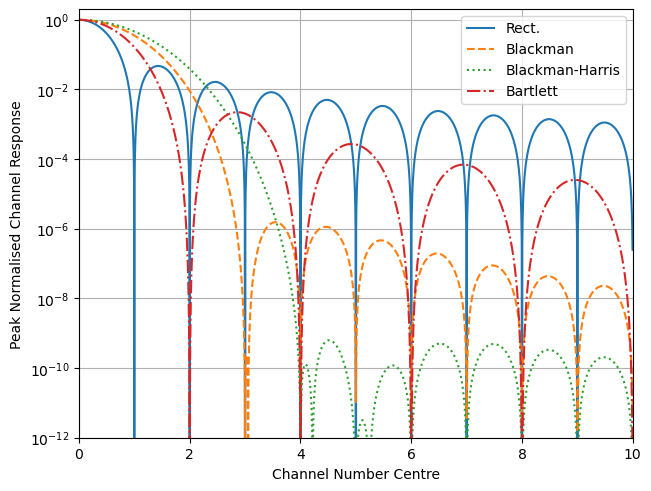

In [3]:

fft_length = 4096
scale = 200

blackman = np.blackman(fft_length)
rectangular = np.ones(fft_length)
bartlett = np.bartlett(fft_length)
hamming = np.hamming(fft_length)
hann = np.hanning(fft_length)
blackman_harris = signal.windows.blackmanharris(fft_length)
cosine = signal.windows.cosine(fft_length)

windows = [rectangular, blackman, blackman_harris,bartlett]
window_list = ['Rect.', 'Blackman', 'Blackman-Harris','Bartlett']
line_styles = ['-', '--', ':', '-.']

fig, axes = plt.subplots(layout='constrained')
for i, w in enumerate(windows):
    W_abs_square = np.abs(np.fft.fft(w, fft_length*scale))**2
    response = W_abs_square / np.max(W_abs_square)
    x_axis = np.linspace(0, fft_length, fft_length*scale) 
    axes.plot(x_axis[:int(10*scale)], response[:int(10*scale)], label=window_list[i], ls=line_styles[i])
axes.set_ylabel('Peak Normalised Channel Response')
axes.set_xlabel('Channel Number Centre')
axes.set_yscale('log')
axes.legend()
axes.grid()
axes.set_ylim(1e-12, 1e0+1)
axes.set_xlim(0, 10)
plt.show()


## Uncorrected Covariance from the CW - No Phase Noise

Plot the Original Covariances For Each Case. Try the 2D imshow for Pearson Correlation Coefficent and Cov and the 1D plot with multiple lines for CW amplitude

0 0
No Switching
0 1
No Switching
0 2
No Switching
0 3
No Switching
0 4
No Switching
1 0
No Switching
1 1
No Switching
1 2
No Switching
1 3
No Switching
1 4
No Switching
2 0
No Switching
2 1
No Switching
2 2
No Switching
2 3
No Switching
2 4
No Switching
3 0
No Switching
3 1
No Switching
3 2
No Switching
3 3
No Switching
3 4
No Switching
4 0
No Switching
4 1
No Switching
4 2
No Switching
4 3
No Switching
4 4
No Switching


/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_88007/4024571728.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_88007/4024571728.py:73: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  jig.show()


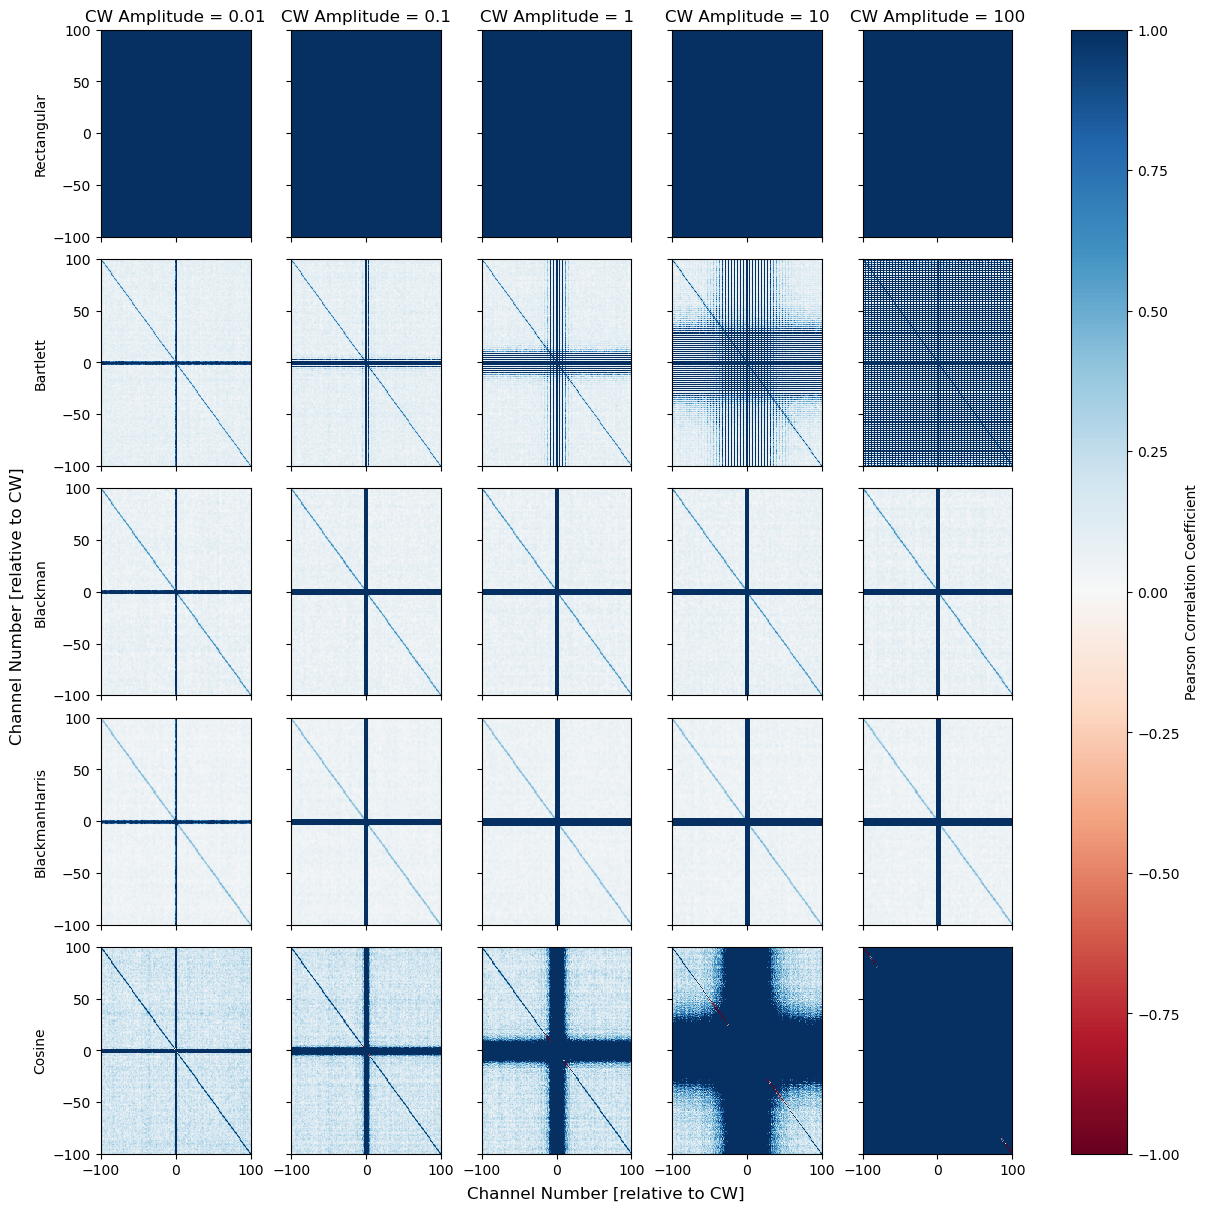

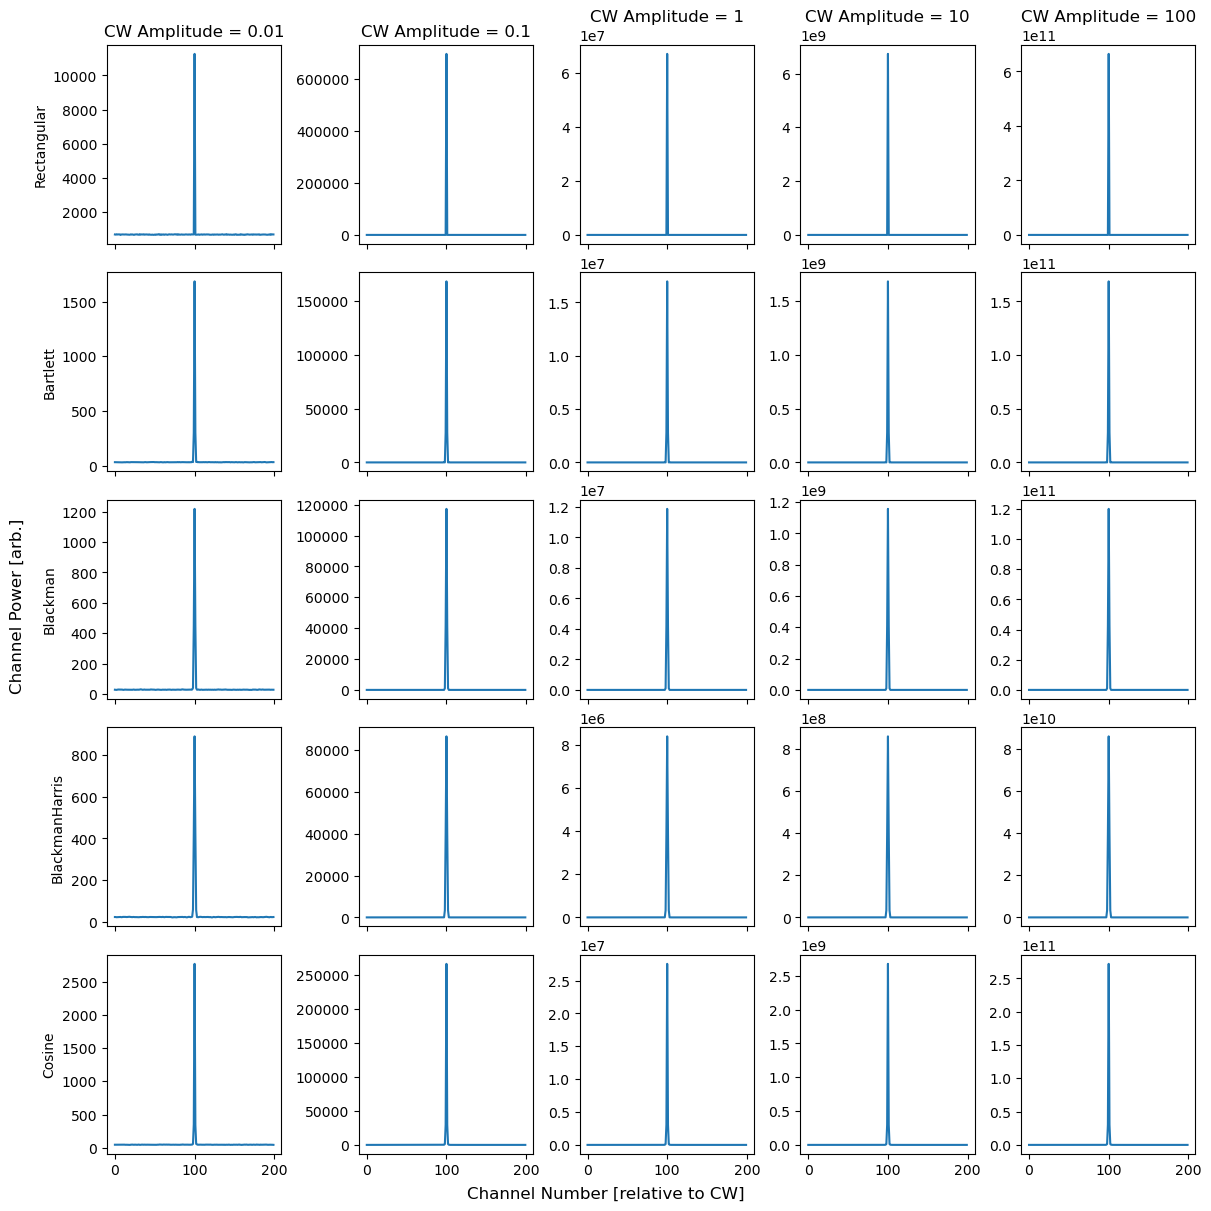

In [60]:
cw_amps = [0.01, 0.1,1,10, 100]
windows = ['Rectangular', 'Bartlett', 'Blackman', 'BlackmanHarris', 'Cosine']

Bartlett_string_list = ['Generated_Data/WindowTests_LaptopRan/winBartlett_cwamp0.01_test.hd5f',
                        'Generated_Data/WindowTests_LaptopRan/winBartlett_cwamp0.1_test.hd5f',
                        'Generated_Data/WindowTests_LaptopRan/winBartlett_cwamp1_test.hd5f',
                        'Generated_Data/WindowTests_LaptopRan/winBartlett_cwamp10_test.hd5f',
                        'Generated_Data/WindowTests_LaptopRan/winBartlett_cwamp100_test.hd5f']

Blackman_string_list = ['Generated_Data/WindowTests_LaptopRan/winBlackman_cwamp0.01_test.hd5f',
                        'Generated_Data/WindowTests_LaptopRan/winBlackman_cwamp0.1_test.hd5f',
                        'Generated_Data/WindowTests_LaptopRan/winBlackman_cwamp1_test.hd5f',
                        'Generated_Data/WindowTests_LaptopRan/winBlackman_cwamp10_test.hd5f',
                        'Generated_Data/WindowTests_LaptopRan/winBlackman_cwamp100_test.hd5f']

BlackmanHarris_string_list = ['Generated_Data/WindowTests_LaptopRan/winBlackmanHarris_cwamp0.01_test.hd5f',
                              'Generated_Data/WindowTests_LaptopRan/winBlackmanHarris_cwamp0.1_test.hd5f',
                              'Generated_Data/WindowTests_LaptopRan/winBlackmanHarris_cwamp1_test.hd5f',
                              'Generated_Data/WindowTests_LaptopRan/winBlackmanHarris_cwamp10_test.hd5f',
                              'Generated_Data/WindowTests_LaptopRan/winBlackmanHarris_cwamp100_test.hd5f']


Cosine_string_list  = ['Generated_Data/WindowTests_LaptopRan/winCosine_cwamp0.01_test.hd5f',
                       'Generated_Data/WindowTests_LaptopRan/winCosine_cwamp0.1_test.hd5f',
                       'Generated_Data/WindowTests_LaptopRan/winCosine_cwamp1_test.hd5f',
                       'Generated_Data/WindowTests_LaptopRan/winCosine_cwamp10_test.hd5f',
                       'Generated_Data/WindowTests_LaptopRan/winCosine_cwamp100_test.hd5f']

Rectanuglar_string_list = ['Generated_Data/WindowTests_LaptopRan/winRectangular_cwamp0.01_test.hd5f',
                           'Generated_Data/WindowTests_LaptopRan/winRectangular_cwamp0.1_test.hd5f',
                           'Generated_Data/WindowTests_LaptopRan/winRectangular_cwamp1_test.hd5f',
                           'Generated_Data/WindowTests_LaptopRan/winRectangular_cwamp10_test.hd5f',
                           'Generated_Data/WindowTests_LaptopRan/winRectangular_cwamp100_test.hd5f']

all_lists = [Rectanuglar_string_list, Bartlett_string_list, Blackman_string_list, BlackmanHarris_string_list, Cosine_string_list]


channel_from_cw = 100
fig, axes = plt.subplots(ncols=len(cw_amps), nrows=len(all_lists), sharex=True, sharey=True, layout='constrained', figsize=(12,12))
jig, laxes = plt.subplots(ncols=len(cw_amps), nrows=len(all_lists), sharex=True, sharey=False, layout='constrained', figsize=(12,12))
vmin, vmax = -1, 1
extent = [-channel_from_cw, channel_from_cw, -channel_from_cw, channel_from_cw]
for i in range(len(cw_amps)):
    for j in range(len(all_lists)):
        print(i,j)
        t = TimeStreamGenerator()
        t.read_in_from_h5py(all_lists[j][i])
        corrcoef = np.cov(t.integrated_spectra.T)
        cw_index = np.argmax(t.integrated_spectra[0])
        im = axes[j,i].imshow(corrcoef[cw_index-channel_from_cw:cw_index+channel_from_cw,
                                       cw_index-channel_from_cw:cw_index+channel_from_cw], 
                                       aspect='auto', vmin=vmin, vmax=vmax, cmap='RdBu', extent=extent, interpolation='None')
        
        laxes[j,i].plot(t.integrated_spectra[0, cw_index-channel_from_cw:cw_index+channel_from_cw])

for i, cw_amp in enumerate(cw_amps):
    axes[0,i].set_title(f'CW Amplitude = {cw_amp}')
    laxes[0,i].set_title(f'CW Amplitude = {cw_amp}')
for j, window in enumerate(windows):
    axes[j, 0].set_ylabel(window)
    laxes[j, 0].set_ylabel(window)


axes_list = [axes[j,i] for j in range(len(windows)) for i in range(len(cw_amps))]
cbar = fig.colorbar(im, ax=axes_list, label='Pearson Correlation Coefficient')

fig.supxlabel('Channel Number [relative to CW]')
fig.supylabel('Channel Number [relative to CW]')
jig.supxlabel('Channel Number [relative to CW]')
jig.supylabel('Channel Power [arb.]')

fig.show()
jig.show()


Plot the Pearson Correlation Coefficient w.r.t the CW channel

Plot for reference the covariance of a channel seperated from the CW by 500 channels

0 0
No Switching
0 1
No Switching
0 2
No Switching
0 3
No Switching
0 4
No Switching
0 5
No Switching
0 6
No Switching
1 0
No Switching
1 1
No Switching
1 2
No Switching
1 3
No Switching
1 4
No Switching
1 5
No Switching
1 6
No Switching
2 0
No Switching
2 1
No Switching
2 2
No Switching
2 3
No Switching
2 4
No Switching
2 5
No Switching
2 6
No Switching


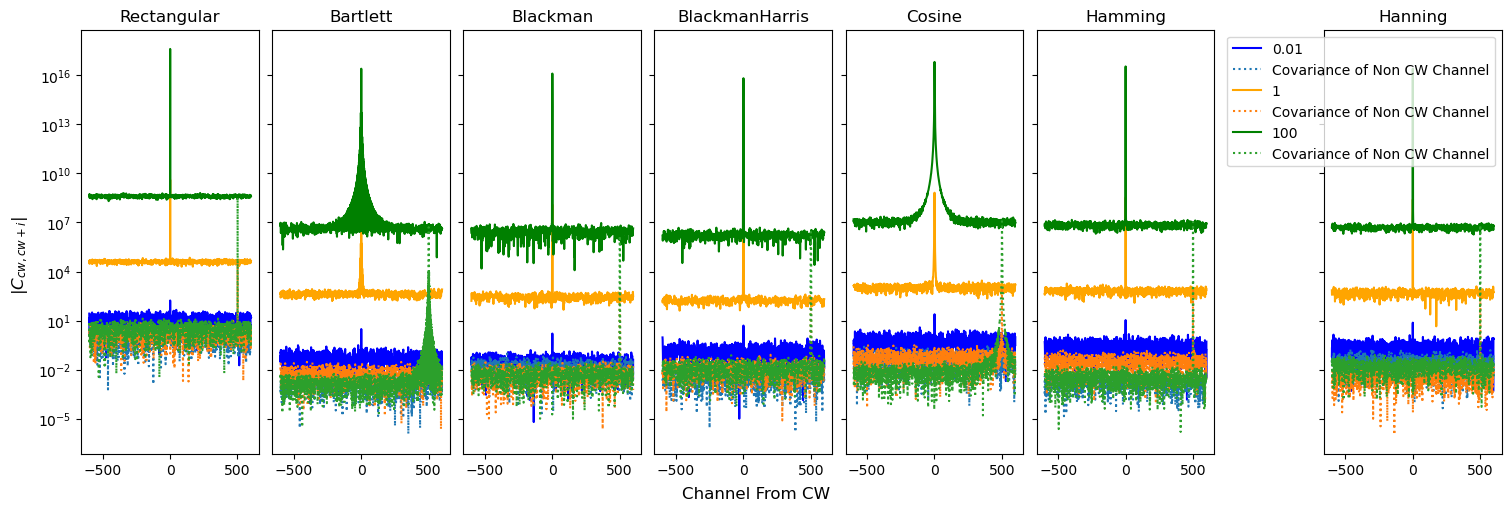

0 0
No Switching
0 1
No Switching
0 2
No Switching
0 3
No Switching
0 4
No Switching
0 5
No Switching
0 6
No Switching
1 0
No Switching
1 1
No Switching
1 2
No Switching
1 3
No Switching
1 4
No Switching
1 5
No Switching
1 6
No Switching
2 0
No Switching
2 1
No Switching
2 2
No Switching
2 3
No Switching
2 4
No Switching
2 5
No Switching
2 6
No Switching


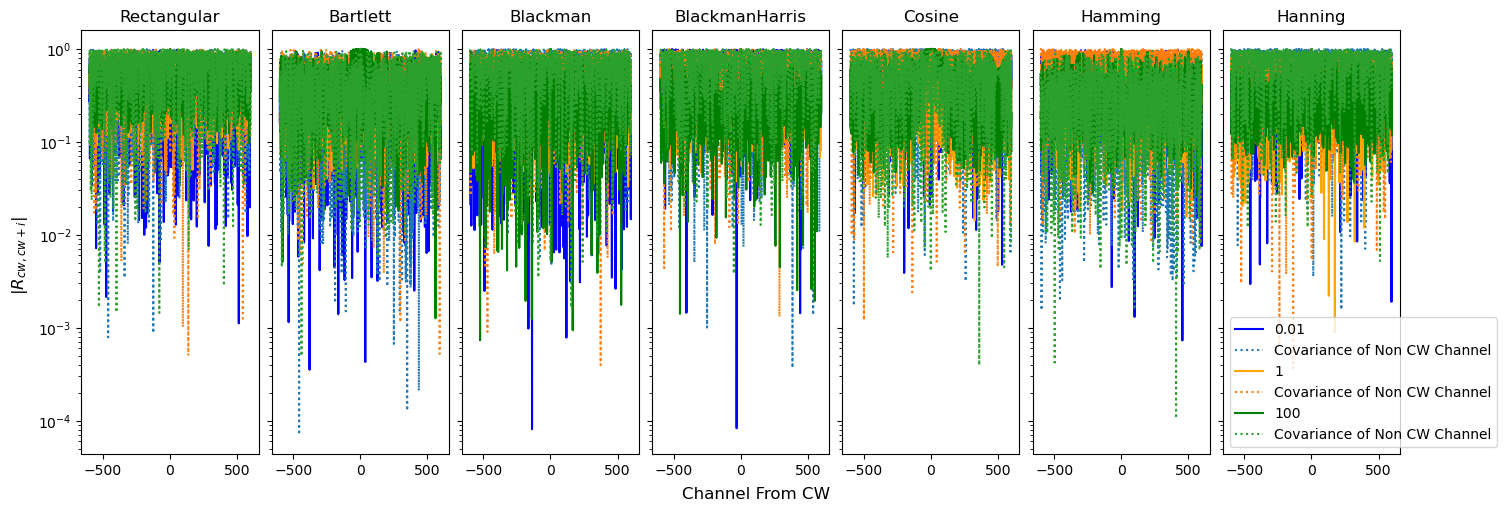

In [ ]:
fig, axes = plt.subplots(ncols=len(windows), sharey=True, figsize=(15,5), layout='constrained')

colors = ['Blue', 'Orange', 'Green']

channel_from_cw = 600
for i, cw_amp in enumerate(cw_amps):
    for j in range(len(all_lists)):
        print(i,j)
        t = TimeStreamGenerator()
        t.read_in_from_h5py(all_lists[j][i])
        corrcoef = np.abs(np.cov(t.integrated_spectra.T))
        cw_index = np.argmax(t.integrated_spectra[0])
        
        # Plot CW Covariance
        axes[j].plot(np.linspace(-channel_from_cw, +channel_from_cw, len(corrcoef[cw_index, cw_index-channel_from_cw:cw_index+channel_from_cw])),
                     corrcoef[cw_index, cw_index-channel_from_cw:cw_index+channel_from_cw], label=cw_amp, c=colors[i])
        axes[j].set_title(windows[j])
        axes[j].set_yscale('log')

        # Plot Covariance of another channel for reference

        axes[j].plot(np.linspace(-channel_from_cw, +channel_from_cw, len(corrcoef[cw_index, cw_index-channel_from_cw:cw_index+channel_from_cw])), 
                     corrcoef[cw_index-500, cw_index-500-channel_from_cw:cw_index-500+channel_from_cw], label=f'Covariance of Non CW Channel', ls=':')

        laxes[j,i].plot(t.integrated_spectra[0, cw_index-channel_from_cw:cw_index+channel_from_cw],c=colors[i])
axes[-1].legend()
fig.supxlabel('Channel From CW')
fig.supylabel(r'$|C_{cw,cw + i}|$')
plt.show()

fig, axes = plt.subplots(ncols=len(windows), sharey=True, figsize=(15,5), layout='constrained')

colors = ['Blue', 'Orange', 'Green']

channel_from_cw = 600
for i, cw_amp in enumerate(cw_amps):
    for j in range(len(all_lists)):
        print(i,j)
        t = TimeStreamGenerator()
        t.read_in_from_h5py(all_lists[j][i])
        corrcoef = np.abs(np.corrcoef(t.integrated_spectra.T))
        cw_index = np.argmax(t.integrated_spectra[0])
        
        # Plot CW Covariance
        axes[j].plot(np.linspace(-channel_from_cw, +channel_from_cw, len(corrcoef[cw_index, cw_index-channel_from_cw:cw_index+channel_from_cw])),
                     corrcoef[cw_index, cw_index-channel_from_cw:cw_index+channel_from_cw], label=cw_amp, c=colors[i])
        axes[j].set_title(windows[j])
        axes[j].set_yscale('log')

        # Plot Covariance of another channel for reference

        axes[j].plot(np.linspace(-channel_from_cw, +channel_from_cw, len(corrcoef[cw_index, cw_index-channel_from_cw:cw_index+channel_from_cw])), 
                     corrcoef[cw_index-500, cw_index-500-channel_from_cw:cw_index-500+channel_from_cw], label=f'Covariance of Non CW Channel', ls=':')

        laxes[j,i].plot(t.integrated_spectra[0, cw_index-channel_from_cw:cw_index+channel_from_cw],c=colors[i])
axes[-1].legend()
fig.supxlabel('Channel From CW')
fig.supylabel(r'$|R_{cw,cw + i}|$')
plt.show()



## Removing Effects of CW spectral leakage

### Leakage from the windowing

For the rectangular window, potentially best to oversample intially and then measure an average response per window.

$P_{\rm src}^{\rm sls} (\nu_i) = P_{\rm src}(\nu_i) - W^2(\nu_{\rm CW} - \nu_i)P_{\rm src}(\nu_{\rm CW})$


Is it possible to iterate over frequencies in which the CW is and convolve from this? Maybe not



For fitting to the CW Power and the channel number and the residual noise

$P(\nu_i) = W^2(\nu_i -\nu_{cw})P_{\rm cw} + P^*_{\rm noise}$
where $\nu_i$ is the channel number, $\nu_{\rm cw}$ is the CW channel number which can be a decimal if it lies in between channels or not directly at the channel centre and $P_{\rm noise}$ is the noise power contribution in a region and is assumed to be constant of the $n$ channels used in this isolation technique.

Boundaries for these values can be set up (like priors); 
 - For the CW channel, if the centre of the channel is at an index of 0, then the CW frequency must be in the range $[-0.5+0.5]$ of the channel with the highest power.
 - For the CW power, the power cannot be less than the power in the CW channel + the noise; This is defined from the fact the CW must be between $[-0.5+0.5]$ ;; $P(\nu_{cw,i})-P_{\rm noise} < P_{\rm cw} < \frac{P(\nu_{cw,i})-P_{\rm noise}}{W^2(0.5)}$
 - For the noise power, can select the channels from [+5:+10] and [-5:-10] and take mean and standard deviation and search within $\pm 5 \sigma_{\rm std}$
 - w.r.t the CW channel (in which the power is greatest), if the channel -1 > channel +1 -> the cw must be between $[-0.5:0]$ and vice versa if channel +1 >  channel -1



 Algorithm -->>
1) Input Uncorrected Spectrum
2) Find cw channel using argmax function
3) if channel +1 >  channel -1:
        define CW frequency range as cw_index:cw_index+0.5
    else:
        define CW frequency range as cw_index-0.5:cw_index
4) subdivide range into $n_{\rm resolution}$ subsection (ideally multiples of 10 so $W^2(0.5)$ may be calculated)
5) for each subsection minimise the function with the model for the contribution to the channels (minimise the sum of the differences between model and data), return minimium difference FoM. Minimise subject to above constraints
6) select minimum FoM to select the frequecy channel and return values of $\nu_{\rm cw}, P_{\rm cw}$ and $P_{\rm noise}$
7) Use these to then subtract off the CW contribution from other channels






Re-Do of the fitting routine but with multiprocessing

'Test_Data/PowerMeterTestsBlackmanNew/wn0.1/tod_cw_fk_0.01.hd5f' = Nice Sample

In [61]:
import scipy.signal
import window_fitting_functions
data = TimeStreamGenerator()

data.read_in_from_h5py('Generated_Data/WindowTests_LaptopRan/winBlackman_cwamp1_test.hd5f')

cw_subtracted_spectra, p_cw, p_n, cw_subchannels = window_fitting_functions.window_cw_fitting_for_array(data.integrated_spectra, np.blackman, sub_channels_per_channel=1000, n_fitting_channels=8)


No Switching


No Switching


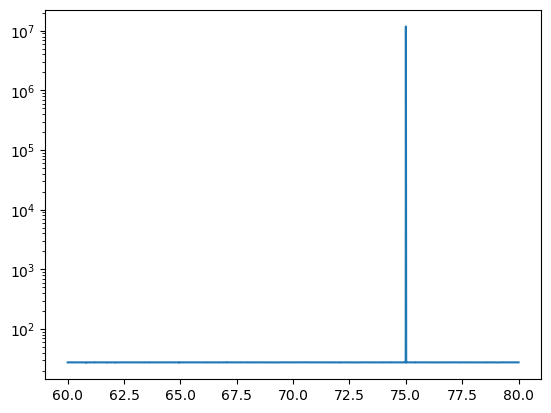

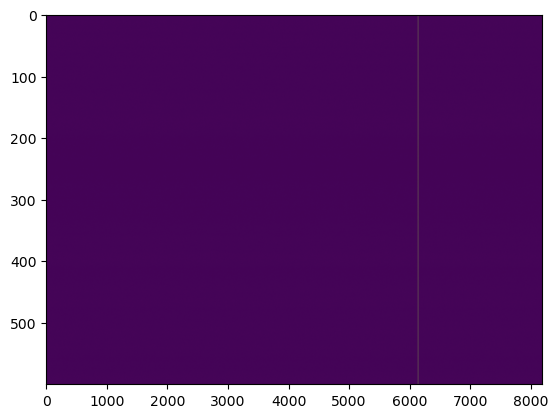

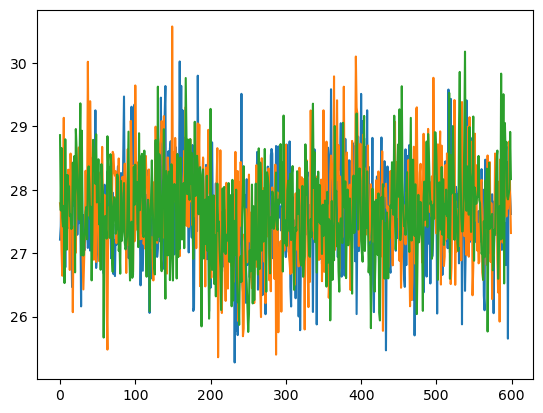

In [62]:
test = TimeStreamGenerator()
test.read_in_from_h5py('Generated_Data/WindowTests_LaptopRan/winBlackman_cwamp1_test.hd5f')

plt.plot(test.frequencies_mhz, np.mean(test.integrated_spectra, axis=0))
plt.yscale('log')
plt.show()

plt.imshow(10*np.log10(test.integrated_spectra), aspect='auto')
plt.show()

plt.plot(test.integrated_spectra[:,100])
plt.plot(test.integrated_spectra[:,500])
plt.plot(test.integrated_spectra[:,1000])
plt.show()

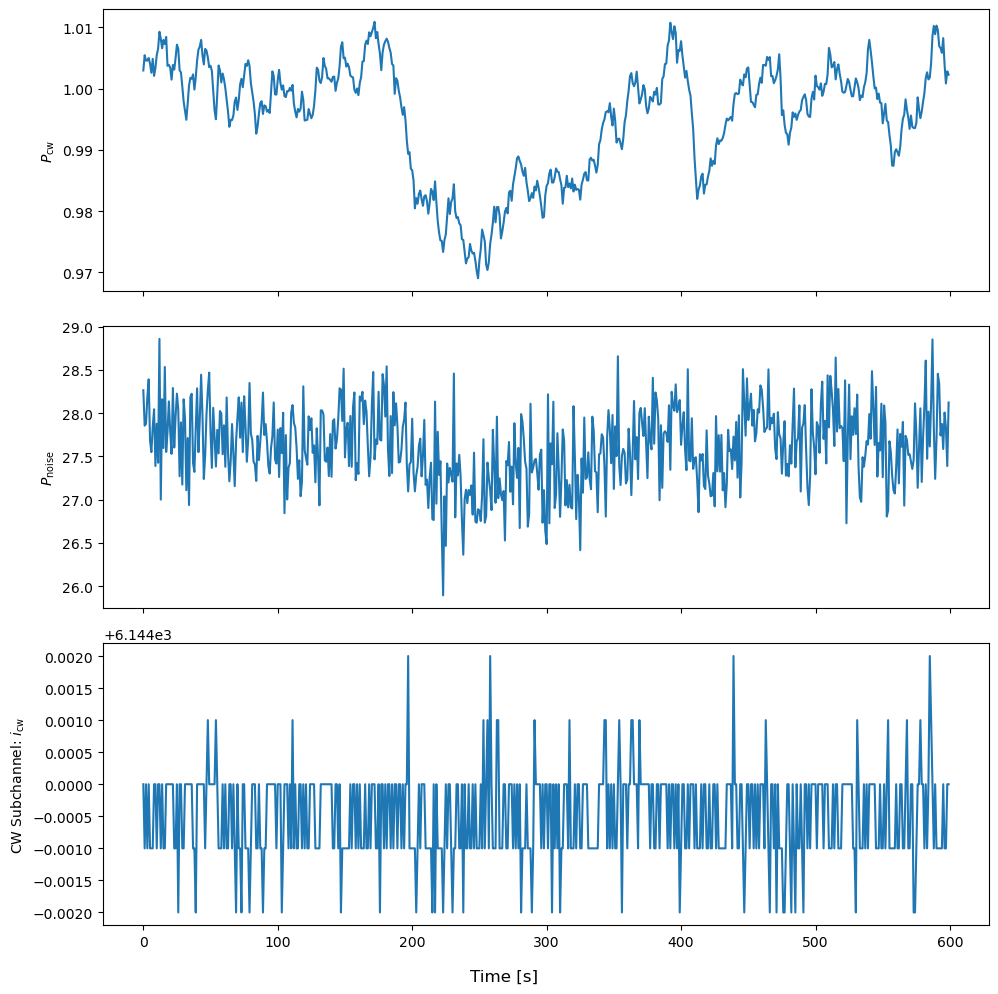

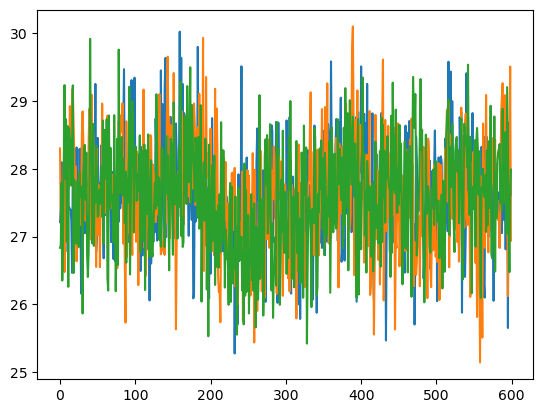

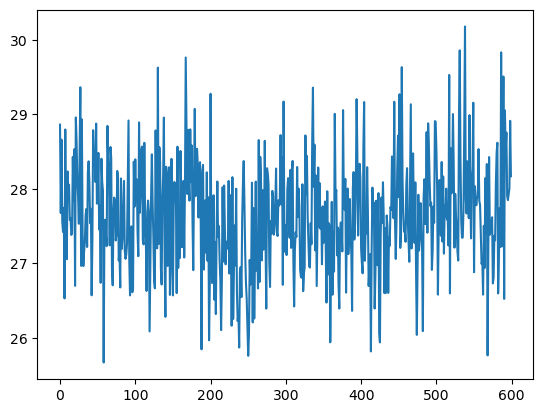

In [63]:
fig, axes = plt.subplots(nrows=3, sharex=True, figsize=(10,10))
axes[0].plot(p_cw)
axes[0].set_ylabel(r'$P_{\rm cw}$')
axes[1].plot(p_n)
axes[1].set_ylabel(r'$P_{\rm noise}$')
axes[2].plot(cw_subchannels)
axes[2].set_ylabel(r'CW Subchannel: $i_{\rm cw}$')
fig.supxlabel('Time [s]')
fig.tight_layout()
plt.show()

plt.plot(data.integrated_spectra[:,100])
plt.plot(data.integrated_spectra[:,200])
plt.plot(data.integrated_spectra[:,300])
plt.show()
plt.plot(data.integrated_spectra[:,1000])
plt.show()

Compare CorrCoeffs

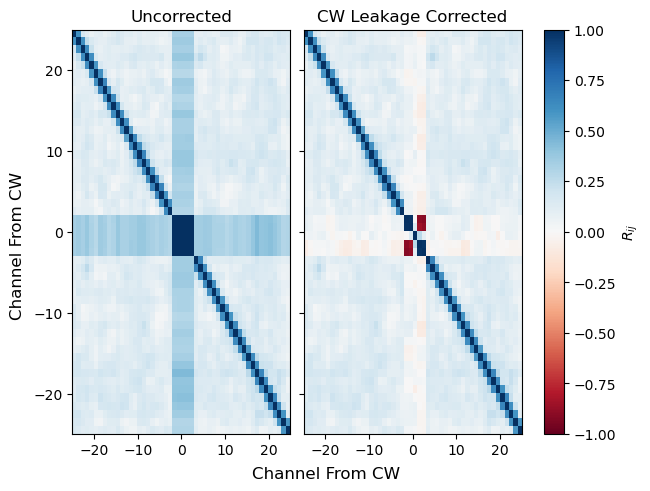

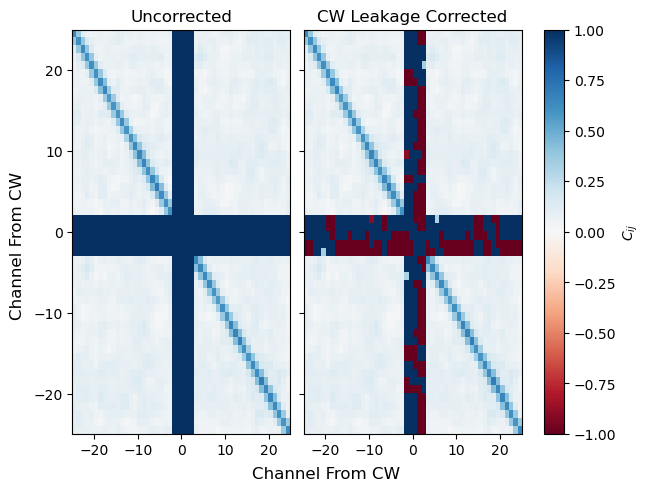

In [64]:
def compare_corr_coeffs(orignal_spectrum, corrected_spectra, cov=False, channel_lim=25):
    cw_index = np.argmax(orignal_spectrum[0])
    
    extent = [-channel_lim, channel_lim, -channel_lim, channel_lim]
    if cov:
        original_corrcoef = np.cov(orignal_spectrum.T)
        corrected_corrcoef = np.cov(corrected_spectra.T)
    else:
        original_corrcoef = np.corrcoef(orignal_spectrum.T)
        corrected_corrcoef = np.corrcoef(corrected_spectra.T)

    vmin, vmax = -1,1
    fig, axes = plt.subplots(ncols=2, sharey=True, layout='constrained')
    
    im = axes[0].imshow(original_corrcoef[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], 
                        vmin=vmin, vmax=vmax, aspect='auto', cmap='RdBu', extent=extent)
    im = axes[1].imshow(corrected_corrcoef[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], 
                        vmin=vmin, vmax=vmax, aspect='auto', cmap='RdBu', extent=extent)
    cbar = fig.colorbar(im, ax=[a for a in axes], label=r'$R_{ij}$')
    axes[0].set_title('Uncorrected')
    axes[1].set_title('CW Leakage Corrected')

    fig.supxlabel('Channel From CW')
    fig.supylabel('Channel From CW')
    plt.show()

def compare_cov(orignal_spectrum, corrected_spectra, channel_lim=25, vmin=0, vmax=3, log=True):
    cw_index = np.argmax(orignal_spectrum[0])
    
    extent = [-channel_lim, channel_lim, -channel_lim, channel_lim]
    if log:
        original_log_cov = np.log10(np.abs(np.cov(orignal_spectrum.T)))
        corrected_log_cov = np.log10(np.abs(np.cov(corrected_spectra.T)))
    else:
        original_log_cov = np.cov(orignal_spectrum.T)
        corrected_log_cov = np.cov(corrected_spectra.T)

    vmin, vmax = -1,1
    fig, axes = plt.subplots(ncols=2, sharey=True, layout='constrained')
    
    im = axes[0].imshow(original_log_cov[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim],
                        aspect='auto', cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
    im = axes[1].imshow(corrected_log_cov[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], 
                        aspect='auto', cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
    if log:
        im = axes[0].imshow(original_log_cov[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim],
                        aspect='auto', cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
        im = axes[1].imshow(corrected_log_cov[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], 
                        aspect='auto', cmap='viridis', extent=extent, vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(im, ax=[a for a in axes], label=r'$\log |C_{ij}|$')
    else:
        im = axes[0].imshow(original_log_cov[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim],
                        aspect='auto', cmap='RdBu', extent=extent, vmin=vmin, vmax=vmax)
        im = axes[1].imshow(corrected_log_cov[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], 
                        aspect='auto', cmap='RdBu', extent=extent, vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(im, ax=[a for a in axes], label=r'$C_{ij}$')
    axes[0].set_title('Uncorrected')
    axes[1].set_title('CW Leakage Corrected')

    fig.supxlabel('Channel From CW')
    fig.supylabel('Channel From CW')
    plt.show()


compare_corr_coeffs(data.integrated_spectra, cw_subtracted_spectra)
compare_cov(data.integrated_spectra, cw_subtracted_spectra, log=False, vmin=-1, vmax=1)
    

Plot the simulated gains vs the gains as measured with CW.
Compare with basic subtraction

In [65]:
def apply_gain_correction(spectra, p_cw, p_pm=None):
    corrected_spectra = []

    if p_pm is not None:
        gains = (p_cw * p_pm[0]) / (p_cw[0] * p_pm)
    else:
        gains = p_cw / p_cw[0]
    
    corrected_spectra = []
    for i, s in enumerate(spectra):
        corrected_spectra.append(s/gains[i])
    corrected_spectra = np.array(corrected_spectra)
    return corrected_spectra

In [66]:
import gains_analysis

aperture_method = gains_analysis.CW_Calibrator(data.integrated_spectra, data.times, data.frequencies_mhz)
aperture_spectra, aperture_gains = aperture_method.otf_gain_calibration(method='Aperture', aperture_bounds=[3,3], return_measured_gains=True)

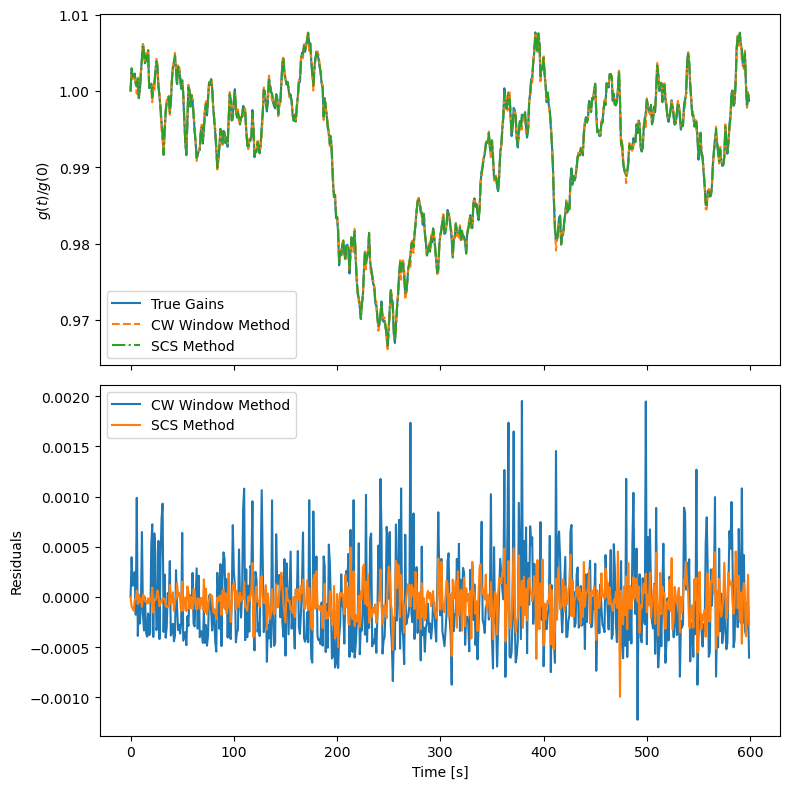

In [67]:
true_gains = np.array([np.mean(g) for g in np.array_split(data.receiver_gains, len(data.times))])
dg_true = true_gains / true_gains[0]
dg_cw = p_cw / p_cw[0]

fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,8))
axes[0].plot(dg_true, label='True Gains')
axes[0].plot(dg_cw, label='CW Window Method', linestyle='--')
axes[0].plot(aperture_gains, label='SCS Method', linestyle='-.')
axes[0].set_ylabel(r'$g(t) / g(0)$')
axes[0].legend()
axes[1].set_ylabel(r'Residuals')
axes[1].plot(dg_true - dg_cw, label='CW Window Method', linestyle='-')
axes[1].plot(dg_true - aperture_gains, label='SCS Method', linestyle='-')
axes[1].legend()
axes[1].set_xlabel('Time [s]')
fig.tight_layout()
plt.show()





Compare PSDs

In [68]:
def compute_PSD(spectra, times, n_to_mask=3):
    cw_indices = [np.argmax(s) for s in spectra]

    min_max_cw_indices = [int(np.min(cw_indices)) - n_to_mask, int(np.max(cw_indices)) + n_to_mask] # create slices to exclude
    mask_indices = np.arange(len(spectra[0]))[min_max_cw_indices[0]:min_max_cw_indices[1]] # indices to mask

    psd_list = []
    for nu, tod in enumerate(spectra.T):
        if nu in mask_indices: # skip channels that are masked
            pass
        else:
            psd = np.abs(np.fft.rfft(tod/np.mean(tod)))
            psd_list.append(psd)

    psd = np.mean(np.array(psd_list), axis=0)
    fft_freqs = np.fft.rfftfreq(n=len(spectra.T[0]), d=times[-1] / len(times))
    return psd, fft_freqs

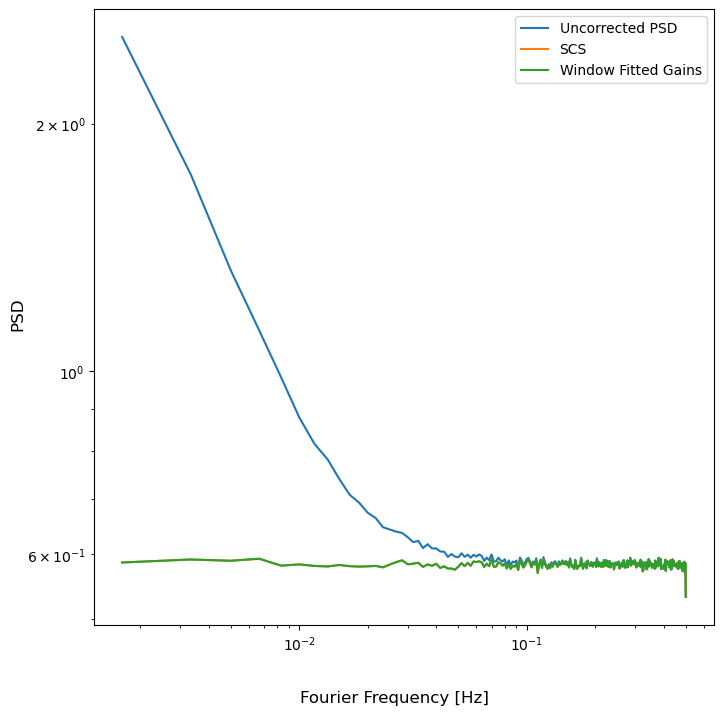

In [69]:
original_psd, fft_freqs = compute_PSD(data.integrated_spectra, data.times, n_to_mask=5)
scs_method_psd,_ = compute_PSD(aperture_spectra, data.times, n_to_mask=5)
window_calibrated_spectra =  apply_gain_correction(spectra=cw_subtracted_spectra, p_cw=p_cw)
window_method_psd,_ = compute_PSD(window_calibrated_spectra, data.times, n_to_mask=5)

fig, axes = plt.subplots(figsize=(8,8))
axes.plot(fft_freqs[1:], original_psd[1:], label='Uncorrected PSD')
axes.plot(fft_freqs[1:], scs_method_psd[1:], label='SCS')
axes.plot(fft_freqs[1:], window_method_psd[1:], label='Window Fitted Gains')
axes.legend()
fig.supylabel('PSD')
fig.supxlabel('Fourier Frequency [Hz]')
axes.set_xscale('log')
axes.set_yscale('log')
plt.show()

## Analysis for all simulated cases

Run the code on all the simulated cases, showing the change in correlation coefficient/covariance before and after the application of the cw subtraction as well as the 1/f correlations.



In [ ]:
#[Rectanuglar_string_list, Bartlett_string_list, Blackman_string_list, BlackmanHarris_string_list, Cosine_string_list]
# cw_amps = [0.01, 0.1, 1, 10, 100]
sub_channels_per_channels_list = [10,100,1000,10000]


original_psd_cw_amp_list = []
scs_psd_cw_amp_list = []
win_resolution_psd_cw_amp_list = []
for filename, cw_amp in zip(Blackman_string_list, cw_amps):
    obs = TimeStreamGenerator()
    obs.read_in_from_h5py(filename)
    original_psd, psd_freqs = compute_PSD(obs.integrated_spectra, obs.times, n_to_mask=10)
    original_psd_cw_amp_list.append(original_psd)

    aperture_method = gains_analysis.CW_Calibrator(obs.integrated_spectra, obs.times, obs.frequencies_mhz)
    aperture_spectra, cw_gains = aperture_method.otf_gain_calibration(method='Aperture', aperture_bounds=[3,3], return_measured_gains=True) # gain calibrated
    scs_method_psd,_ = compute_PSD(aperture_spectra, data.times, n_to_mask=10)
    scs_psd_cw_amp_list.append(scs_method_psd)

    sub_channel_psds = [] # psd results from applying p_cw to psd
    sub_channel_gain_calibrated_spectra = [] # corrected spectra with both cw and 
    sub_channel_corrected_spectra = [] # just corrected

    for subchannel_per_channel in sub_channels_per_channels_list: # compute the 
        
        cw_corrected_spectra, p_cw, p_n, cw_subchannels = window_fitting_functions.window_cw_fitting_for_array(obs.integrated_spectra,
                                                                                                               np.blackman,
                                                                                                               sub_channels_per_channel=subchannel_per_channel,
                                                                                                               n_fitting_channels=8, plot=False)

        window_calibrated_spectra =  apply_gain_correction(spectra=cw_corrected_spectra, p_cw=p_cw)

        window_method_psd,_ = compute_PSD(window_calibrated_spectra, data.times, n_to_mask=10)

        sub_channel_psds.append(window_method_psd)
        sub_channel_corrected_spectra.append(cw_corrected_spectra)
        sub_channel_gain_calibrated_spectra.append(window_calibrated_spectra)

        
        pass
    
    psd_freqs = psd_freqs
    win_resolution_psd_cw_amp_list.append(sub_channel_psds)

    pass



No Switching
No Switching
No Switching
No Switching
No Switching


In [ ]:
fig, axes = plt.subplots(ncols=len(cw_amps), nrows=len(sub_channels_per_channels_list),sharey=True)
for j in range(len(cw_amps)):
    for i in range(len(sub_channels_per_channels_list)):
        axes[i,j].plot(psd_freqs[1:], original_psd_cw_amp_list[i][1:], label='Uncorrected', c='b')
        axes[i,j].plot(psd_freqs[1:], scs_psd_cw_amp_list[i][1:], label='SCS Method', c='r')
        axes[i,j].plot(psd_freqs[1:], win_resolution_psd_cw_amp_list[j][i][1:], label='Window Method', c='g')
        axes[i,j].set_yscale('log')
        axes[i,j].set_xscale('log')
        axes[i,0].set_ylabel(f'WR = {sub_channels_per_channels_list[i]}')
    title_string = r'$A_{cw} = $'+str(cw_amps[j])
    axes[0,j].set_title(title_string)
axes[0,0].legend()
fig.supxlabel('Fourier Frequency')
fig.supylabel('PSD')
plt.show()

# save data

In [ ]:
import h5py
import os
save_path = 'Test_Results/Window_Tests'
if not os.path.exists(path=save_path):
    os.makedirs(save_path)
    print('Save Path Created')
else:
    print('Save Path Set Up')
save_path = save_path+'/'

with h5py.File(f'{save_path}/Rectangular_Test.hd5f', mode='w') as file:
    for i, cw_amp in enumerate(cw_amps):
        cw_amp_grp = file.create_group(f'{cw_amp}')
        
        original_psd = original_psd_cw_amp_list[i]
        cw_amp_grp.create_dataset('Original_PSD', data=original_psd, dtype=original_psd.dtype)
        cw_amp_grp.create_dataset('PSD_Freqs', data=psd_freqs, dtype=psd_freqs.dtype)

        scs_psd = scs_psd_cw_amp_list[i]
        cw_amp_grp.create_dataset('SCS_PSD', data=scs_psd, dtype=scs_psd.dtype)

        sub_channel_psd_list = win_resolution_psd_cw_amp_list[i]

        window_test_grp = cw_amp_grp.create_group('WindowTests')
        for j, sub_channel_res in enumerate(sub_channels_per_channels_list):
            window_psd = sub_channels_per_channels_list[j]
            window_test_grp.create_dataset(f'Window_{sub_channel_res}_PSD', data=window_psd, dtype=window_psd.dtype)
            



# Below This is outdated. Don't use

In [27]:


import scipy.optimize


def produce_channel_subdivisions(window_function=np.blackman, fft_length=1024, resolution=10):
    window = window_function(fft_length)
    W_abs_square = np.abs(np.fft.fft(window, n=fft_length*resolution))**2
    W_abs_square = W_abs_square / W_abs_square[0]
    subchannels = np.linspace(0, fft_length, fft_length*resolution)

    channel_limit_response = W_abs_square[int(resolution/2)]

    #W_abs_square = np.roll(W_abs_square, shift=10)

    return W_abs_square, channel_limit_response

def return_W_index(index, cw_subchannel, resolution=10):
    #cw_subchannel = round(cw_subchannel, int(np.log10(resolution))) 
    return int(np.abs(cw_subchannel-index)*resolution)

def model_power_func(channel_index, cw_subindex, cw_power, noise_power, W_abs_square_array, resolution):
    W_abs_square = W_abs_square_array[return_W_index(channel_index, cw_subindex, resolution)]
    channel_power = W_abs_square*cw_power + noise_power
    return channel_power


def spectra_cw_window_calibrate(spectra, w_abs_squared, channel_lim_response,subchannel_res = 0.1, n_channel_fits=2,
                                plot=False, return_params=False):
    
    cw_index = np.argmax(spectra) # get the index with the highest CW frequency
    fft_length = len(spectra)

    resolution = int(1/subchannel_res)

    

    if spectra[cw_index+1] > spectra[cw_index-1]:
        cw_subchannel_lim = [cw_index, cw_index+0.5]
    else:
        cw_subchannel_lim = [cw_index-0.5, cw_index]

    cw_subchannel_lim = [cw_index-0.5, cw_index+0.5] # define range for the cw subchannel scan FIXME add 0 -> 0.5 and vice versa for scanning

    fitting_channels = spectra[cw_index-n_channel_fits:cw_index+n_channel_fits]    #define channels for fitting and the indices
    fitting_indices = np.arange(start=cw_index-n_channel_fits, stop=cw_index+n_channel_fits)



    cw_subchannel_list = np.arange(start=cw_subchannel_lim[0], stop=cw_subchannel_lim[-1]+subchannel_res,
                                   step=subchannel_res) # define range for subchannel scanning

    # priors and initial values for fitting #FIXME
    prior_n_p_mean = np.mean(spectra[cw_index+n_channel_fits+1:cw_index+n_channel_fits+10])
    prior_n_p_span = 5 * np.mean(spectra[cw_index+n_channel_fits+1:cw_index+n_channel_fits+10])

    p_cw_min = np.max(spectra) - 2 * prior_n_p_mean
    p_cw_max = (np.max(spectra) - prior_n_p_mean) / channel_lim_response
    p_cw_0 = np.mean(np.array([p_cw_min, p_cw_max]))



    x0 = [p_cw_0, prior_n_p_mean]# starting parameters for the minimisation
    x_lims = 3# FIXME limits for minimisation

    FoMs = []       # list of FoMs
    results = []    # list of resulst

    for cw_subchannel in cw_subchannel_list: # go through each CW subchannel and fit for P_cw and P_noise
        w_abs_indices = np.array([return_W_index(i, cw_subchannel, resolution) for i in fitting_indices])
        w_abs_values = w_abs_squared[w_abs_indices]

        model_power = lambda x : (x[0]*w_abs_values)+x[1]

        fom_function = lambda x: np.sum(np.abs(fitting_channels - model_power(x)) / fitting_channels)

        res = scipy.optimize.minimize(fom_function, x0=x0) # minimise the fractional error to not bias the fitting
        
        FoMs.append(res.fun)
        results.append(res.x)
    
    if plot: # plot FoMs
        plt.plot(cw_subchannel_list, FoMs)
        plt.show()

    FoMs = np.array(FoMs)

    

    optimum_results = results[np.argmin(FoMs)] # [P_cw, P_noise]
    optimum_cw_subchannel = cw_subchannel_list[np.argmin(FoMs)] # get cw sub channel with optimal FoM

    p_cw, p_noise = optimum_results

    if plot:
        fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,8))
        axes[0].plot(fitting_indices, fitting_channels, label='Data')
        axes[0].set_yscale('log')
        axes[0].set_ylabel('Channel Power')
        model_values = np.array([model_power_func(i, cw_subindex=optimum_cw_subchannel,
                                        cw_power=optimum_results[0], noise_power=optimum_results[1],
                                        W_abs_square_array=w_abs_squared, resolution=resolution) for i in fitting_indices])
        axes[0].plot(fitting_indices, model_values, label='Best Fit')
        axes[0].legend()

        axes[1].plot(fitting_indices, model_values - fitting_channels)
        axes[1].set_ylabel('Residuals [arb]')
        axes[1].set_xlabel('Frequency Channel')
        fig.tight_layout()

        plt.show()
        # FIXME fix the fitting function and add a condition that p_noise can't be less than zero

    # with the values of P_cw and the subchannel, calculate the CW contribution in all other channels.


    # modulus the cw_subchannel to remove numerical error
    optimum_cw_subchannel = round(optimum_cw_subchannel, int(np.log10(resolution))+2)

    # calculate the CW power per channel using the difference between the channel indicies

    cw_leaked_powers = np.array([p_cw * w_abs_squared[return_W_index(index, optimum_cw_subchannel, resolution)] for index in np.arange(fft_length)]) # check this

    if plot:
        plt.plot(cw_leaked_powers)
        plt.yscale('log')
        plt.show()
    
    cal_spectra = spectra - cw_leaked_powers

    if plot:
        plt.plot(cal_spectra[fitting_indices], label='CW corrected')
        plt.plot(spectra[fitting_indices], label='Uncorrected')
        plt.ylabel('CW subtracted spectra')
        plt.legend()
        plt.yscale('log')
        plt.show()
    
    if return_params:
        return cal_spectra, [p_cw, p_noise, optimum_cw_subchannel]
    else:
        return cal_spectra
    






def window_function_calibration(spectra, window_function, sub_channel_resolution=0.01, n_fitting_channels=5, return_params=False):
    resolution = int(1 / sub_channel_resolution)
    w_abs_squared, channel_lim = produce_channel_subdivisions(window_function=window_function,
                                                              fft_length=len(spectra[0]),
                                                              resolution=resolution)
    

    corrected_spectra_params = [spectra_cw_window_calibrate(spectra=s, w_abs_squared=w_abs_squared, channel_lim_response=channel_lim,
                                                            subchannel_res=sub_channel_resolution, n_channel_fits=n_fitting_channels,
                                                            plot=False, return_params=True) for s in spectra]

    corrected_spectra = np.array([s for s,_ in corrected_spectra_params])
    print('done')
    if return_params:
        extracted_params = np.array([p for _,p in corrected_spectra_params])
        return corrected_spectra, extracted_params
    else:
        return corrected_spectra
    





In [125]:
return_W_index(200, 201.84215, resolution=1/0.01)

184

Work in Progress:: Making the minimise operate over continous channel boundaries with scip minimise

In [126]:
import scipy.optimize



def spectra_cw_window_calibrate_wip(spectra, w_abs_squared, channel_lim_response,subchannel_res = 0.1, n_channel_fits=2, plot=False, return_params=False):
    """
    spectra - single spectrum of length fft_length
    w_abs_squared - the window response of the function centred at index 0 with a length of fft_length / subchannel_resolution
    channel_limit_response - the normalised response of the window function w.r.t the centre at a spacing of 0.5 channels to demark the channel boundary
    """

    cw_index = np.argmax(spectra) # get the index with the highest CW frequency
    fft_length = len(spectra)

    resolution = int(1/subchannel_res)

    if spectra[cw_index+1] > spectra[cw_index-1]:
        cw_subchannel_lim = [cw_index, cw_index+1]
    else:
        cw_subchannel_lim = [cw_index-1, cw_index]
    cw_subchannel_lim = [cw_index-0.5, cw_index+0.5]

    fitting_channels = spectra[cw_index-n_channel_fits:cw_index+n_channel_fits+1]    #define channels for fitting and the indices
    fitting_indices = np.arange(start=cw_index-n_channel_fits, stop=cw_index+n_channel_fits+1) # define the indicies of the fitting channels

    # priors and initial values for fitting #FIXME
    prior_n_p_mean = np.mean(spectra[cw_index+n_channel_fits+1:cw_index+n_channel_fits+10])
    prior_n_p_span = 5 * np.std(spectra[cw_index+n_channel_fits+1:cw_index+n_channel_fits+10]) # FIXME comment out what is not needed
    p_noise_lb, p_noise_hb = prior_n_p_mean - prior_n_p_span, prior_n_p_mean + prior_n_p_span

    p_cw_min = np.max(spectra) - 2 * prior_n_p_mean
    p_cw_max = (np.max(spectra) - prior_n_p_mean) / channel_lim_response
  
    p_cw_0 = np.mean(np.array([p_cw_min, p_cw_max]))

    #bounds = scipy.optimize.Bounds([p_cw_min, p_noise_lb, cw_subchannel_lim[0]], [p_cw_max, p_noise_hb, cw_subchannel_lim[1]])
    x0 = [p_cw_0, prior_n_p_mean, float(cw_index)+25*subchannel_res]# starting parameters for the minimisation



    model_power = lambda x : (x[0]*w_abs_squared[np.array([return_W_index(i, x[2], resolution) for i in fitting_indices])])+ x[1]
    fom_function = lambda x: np.sum(np.abs(fitting_channels - model_power(x)) / fitting_channels)

    #res = scipy.optimize.minimize(fom_function, x0=x0, method='SLSQP') # FIXME not scanning in frequency
    res = scipy.optimize.basinhopping(fom_function, x0=x0, niter=500)
    print(res)

    results = res.x
    print(results)
    p_cw, p_noise, cw_subchannel = results

    scipy.optimize.newton()

    #cw_subchannel = round(cw_subchannel, int(np.log10(resolution)))

    if plot:
        fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(8,8))
        axes[0].plot(fitting_indices, fitting_channels, label='Data')
        axes[0].set_yscale('log')
        axes[0].set_ylabel('Channel Power')
        model_values = np.array([model_power_func(i, cw_subindex=cw_subchannel,
                                        cw_power=p_cw, noise_power=p_noise,
                                        W_abs_square_array=w_abs_squared, resolution=resolution) for i in fitting_indices])
        axes[0].plot(fitting_indices, model_values, label='Best Fit')
        axes[0].legend()

        axes[1].plot(fitting_indices, model_values - fitting_channels)
        axes[1].set_ylabel('Residuals [arb]')
        axes[1].set_xlabel('Frequency Channel')
        fig.tight_layout()

        plt.show()
        # FIXME fix the fitting function and add a condition that p_noise can't be less than zero

    # calculate the CW power per channel using the difference between the channel indicies

    cw_leaked_powers = np.array([p_cw * w_abs_squared[return_W_index(index, cw_subchannel, resolution)] for index in np.arange(fft_length)]) # check this

    if plot:
        plt.plot(cw_leaked_powers)
        plt.yscale('log')
        plt.show()
    
    cal_spectra = spectra - cw_leaked_powers

    if plot:
        plt.plot(cal_spectra[fitting_indices], label='CW corrected')
        plt.plot(spectra[fitting_indices], label='Uncorrected')
        plt.ylabel('CW subtracted spectra')
        plt.legend()
        plt.yscale('log')
        plt.show()
    
    if return_params:
        return cal_spectra, [p_cw, p_noise, cw_subchannel]
    else:
        return cal_spectra
    
data = TimeStreamGenerator()
data.read_in_from_h5py('Generated_Data/WindowTests/winBlackman_cwamp0.01_test.hd5f')

w_abs_squared, channel_lim_response = produce_channel_subdivisions(np.blackman, len(data.integrated_spectra[0]), resolution=10000)


No Switching


In [127]:

corrected_spectra = spectra_cw_window_calibrate(data.integrated_spectra[300], w_abs_squared, channel_lim_response,subchannel_res = 0.0001, n_channel_fits=5, plot=True, return_params=False)


KeyboardInterrupt: 

Write Muliproccessing Code to speed things up

In [ ]:
def mp_process_spectra(spectra, window_function, sub_channel_resolution=0.01, n_fitting_channels=5, return_params=False):
    resolution = int(1 / sub_channel_resolution)
    w_abs_squared, channel_lim = produce_channel_subdivisions(window_function=window_function,
                                                              fft_length=len(spectra[0]),
                                                              resolution=resolution)
    
    #correct_spectrum_no_params = lambda spectrum : spectra_cw_window_calibrate(spectrum, w_abs_squared=w_abs_squared, channel_lim_response=channel_lim,
    #                                                                           subchannel_res=sub_channel_resolution, n_channel_fits=n_fitting_channels, 
     #                                                                          return_params=False)
    
    correct_spectrum_no_params = partial(spectra_cw_window_calibrate, w_abs_squared, w_abs_squared=w_abs_squared, channel_lim_response=channel_lim,
                                                                               subchannel_res=sub_channel_resolution, n_channel_fits=n_fitting_channels, 
                                                                               return_params=False)

    correct_spectrum_with_params = partial(spectra_cw_window_calibrate, w_abs_squared, w_abs_squared=w_abs_squared, channel_lim_response=channel_lim,
                                                                               subchannel_res=sub_channel_resolution, n_channel_fits=n_fitting_channels, 
                                                                               return_params=True)
    #correct_spectrum_with_params = lambda spectrum : spectra_cw_window_calibrate(spectrum, w_abs_squared, channel_lim,
     #                                                                          sub_channel_resolution, n_fitting_channels, 
      #                                                                         return_params=True)
    

    with multiprocessing.Pool() as pool:
        if return_params:
            spectra = [s for s in spectra]
            corrected_spectra_params = pool.starmap(correct_spectrum_with_params, spectra)
            corrected_spectra = np.array([s for s,_ in corrected_spectra_params])
            fitted_parms = np.array([p for _,p in corrected_spectra_params])
            return corrected_spectra, fitted_parms
        else:
            spectra = [s for s in spectra]
            corrected_spectra = pool.starmap(correct_spectrum_no_params, spectra)
            corrected_spectra = np.array(corrected_spectra)
            return corrected_spectra


data = TimeStreamGenerator()
data.read_in_from_h5py('Generated_Data/WindowTests/winBlackmanHarris_cwamp100_test.hd5f')

corrected_spectra = mp_process_spectra(data.integrated_spectra, window_function=signal.windows.blackmanharris)

No Switching


Process SpawnPoolWorker-153:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/beam_env_safe/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/beam_env_safe/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/anaconda3/envs/beam_env_safe/lib/python3.11/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/opt/anaconda3/envs/beam_env_safe/lib/python3.11/multiprocessing/queues.py", line 367, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'spectra_cw_window_calibrate' on <module '__main__' (built-in)>
Process SpawnPoolWorker-157:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/beam_env_safe/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/anaconda3/envs/beam_env_safe/lib/python3.11/m

KeyboardInterrupt: 

Test for covariance

In [ ]:
data = TimeStreamGenerator()
data.read_in_from_h5py('Generated_Data/WindowTests/winBlackmanHarris_cwamp100_test.hd5f')

w_abs_squared, channel_limit = produce_channel_subdivisions(window_function=signal.windows.blackmanharris, fft_length=len(data.integrated_spectra[0]),
                                                            resolution=1000)

corrected_spectra = np.array([spectra_cw_window_calibrate(spectra=t, w_abs_squared=w_abs_squared, channel_lim_response=channel_limit,
                                          subchannel_res=0.001, n_channel_fits=10,plot=False) for t in data.integrated_spectra])

No Switching


/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_34361/3654388935.py:1: RuntimeWarning: invalid value encountered in log10
  cov_initial = np.log10(np.cov(data.integrated_spectra.T))
/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_34361/3654388935.py:2: RuntimeWarning: invalid value encountered in log10
  cov_corrected = np.log10(np.cov(corrected_spectra.T))


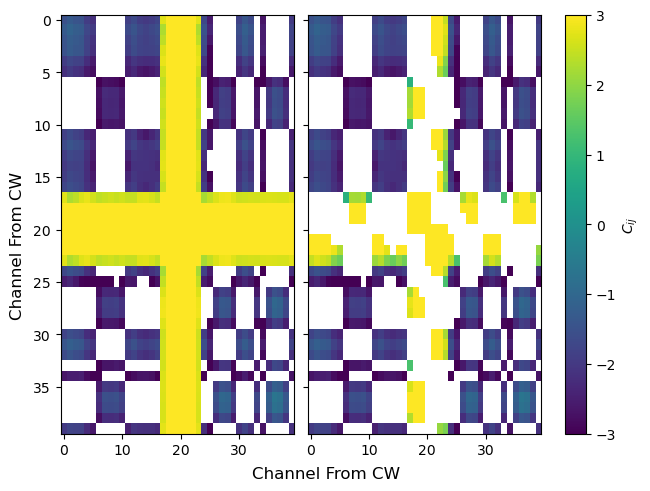

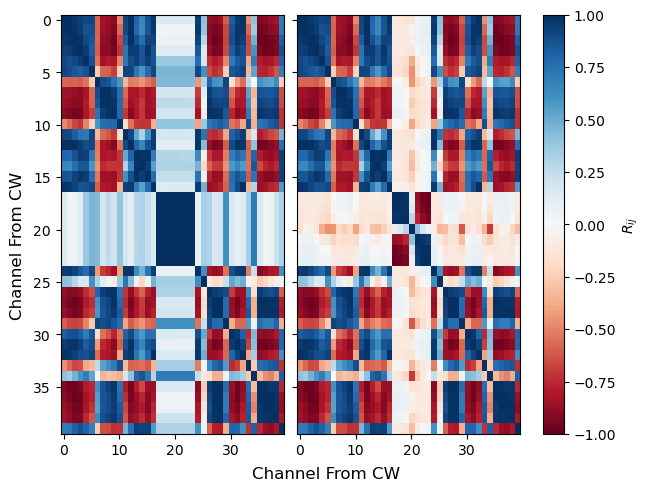

In [ ]:
cov_initial = np.log10(np.cov(data.integrated_spectra.T))
cov_corrected = np.log10(np.cov(corrected_spectra.T))

cw_index = np.argmax(data.integrated_spectra[0])
channel_lim = 20

vmin, vmax = -3,3
fig, axes = plt.subplots(ncols=2, sharey=True, layout='constrained')

im = axes[0].imshow(cov_initial[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], vmin=vmin, vmax=vmax, aspect='auto')
im = axes[1].imshow(cov_corrected[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], vmin=vmin, vmax=vmax, aspect='auto')
cbar = fig.colorbar(im, ax=[a for a in axes], label=r'$C_{ij}$')
fig.supxlabel('Channel From CW')
fig.supylabel('Channel From CW')
plt.show()

cov_initial = np.corrcoef(data.integrated_spectra.T)
cov_corrected = np.corrcoef(corrected_spectra.T)

cw_index = np.argmax(data.integrated_spectra[0])

vmin, vmax = -1,1
fig, axes = plt.subplots(ncols=2, sharey=True, layout='constrained')

im = axes[0].imshow(cov_initial[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], vmin=vmin, vmax=vmax, aspect='auto', cmap='RdBu')
im = axes[1].imshow(cov_corrected[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], vmin=vmin, vmax=vmax, aspect='auto', cmap='RdBu')
cbar = fig.colorbar(im, ax=[a for a in axes], label=r'$R_{ij}$')
fig.supxlabel('Channel From CW')
fig.supylabel('Channel From CW')
plt.show()

No Switching


/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_34361/1460343921.py:10: RuntimeWarning: invalid value encountered in log10
  cov_initial = np.log10(np.cov(data.integrated_spectra.T))
/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_34361/1460343921.py:11: RuntimeWarning: invalid value encountered in log10
  cov_corrected = np.log10(np.cov(corrected_spectra.T))


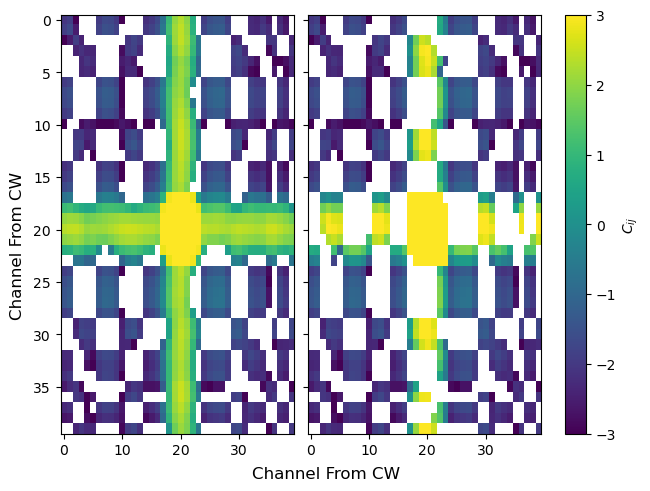

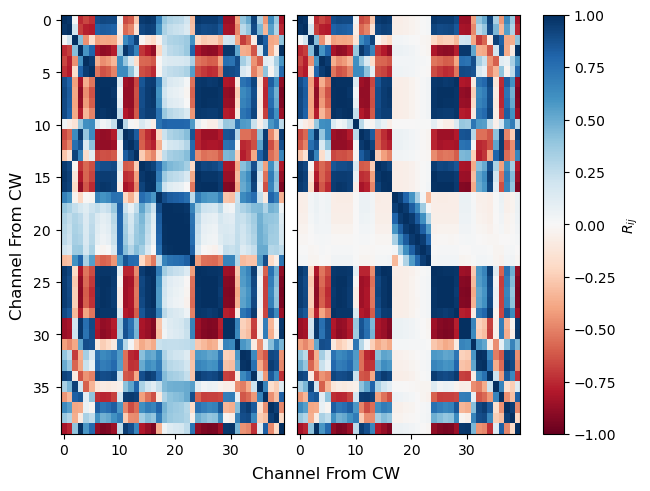

In [ ]:
data = TimeStreamGenerator()
data.read_in_from_h5py('Generated_Data/WindowTests/winBlackmanHarris_cwamp1_test.hd5f')

w_abs_squared, channel_limit = produce_channel_subdivisions(window_function=signal.windows.blackmanharris, fft_length=len(data.integrated_spectra[0]),
                                                            resolution=1000)

corrected_spectra = np.array([spectra_cw_window_calibrate(spectra=t, w_abs_squared=w_abs_squared, channel_lim_response=channel_limit,
                                          subchannel_res=0.001, n_channel_fits=10,plot=False) for t in data.integrated_spectra])

cov_initial = np.log10(np.cov(data.integrated_spectra.T))
cov_corrected = np.log10(np.cov(corrected_spectra.T))

cw_index = np.argmax(data.integrated_spectra[0])
channel_lim = 20

vmin, vmax = -3,3
fig, axes = plt.subplots(ncols=2, sharey=True, layout='constrained')

im = axes[0].imshow(cov_initial[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], vmin=vmin, vmax=vmax, aspect='auto')
im = axes[1].imshow(cov_corrected[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], vmin=vmin, vmax=vmax, aspect='auto')
cbar = fig.colorbar(im, ax=[a for a in axes], label=r'$C_{ij}$')
fig.supxlabel('Channel From CW')
fig.supylabel('Channel From CW')
plt.show()

cov_initial = np.corrcoef(data.integrated_spectra.T)
cov_corrected = np.corrcoef(corrected_spectra.T)

cw_index = np.argmax(data.integrated_spectra[0])

vmin, vmax = -1,1
fig, axes = plt.subplots(ncols=2, sharey=True, layout='constrained')

im = axes[0].imshow(cov_initial[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], vmin=vmin, vmax=vmax, aspect='auto', cmap='RdBu')
im = axes[1].imshow(cov_corrected[cw_index-channel_lim:cw_index+channel_lim, cw_index-channel_lim:cw_index+channel_lim], vmin=vmin, vmax=vmax, aspect='auto', cmap='RdBu')
cbar = fig.colorbar(im, ax=[a for a in axes], label=r'$R_{ij}$')
fig.supxlabel('Channel From CW')
fig.supylabel('Channel From CW')
plt.show()


# Comparison of Resolution and CW Strenght in Computing the Decorrelated Matrix

In [ ]:
cw_amps = [0.01, 1, 100]
sub_channel_resolutions = [0.1, 0.01]#, 0.001]

windows = ['Rectangular', 'Bartlett', 'Blackman', 'BlackmanHarris', 'Cosine', 'Hamming', 'Hanning']

Bartlett_string_list = ['Generated_Data/WindowTests/winBartlett_cwamp0.01_test.hd5f', 'Generated_Data/WindowTests/winBartlett_cwamp1_test.hd5f', 'Generated_Data/WindowTests/winBartlett_cwamp100_test.hd5f']
Blackman_string_list = ['Generated_Data/WindowTests/winBlackman_cwamp0.01_test.hd5f', 'Generated_Data/WindowTests/winBlackman_cwamp1_test.hd5f', 'Generated_Data/WindowTests/winBlackman_cwamp100_test.hd5f']
BlackmanHarris_string_list = ['Generated_Data/WindowTests/winBlackmanHarris_cwamp0.01_test.hd5f', 'Generated_Data/WindowTests/winBlackmanHarris_cwamp1_test.hd5f', 'Generated_Data/WindowTests/winBlackmanHarris_cwamp100_test.hd5f']
Cosine_string_list  = ['Generated_Data/WindowTests/winCosine_cwamp0.01_test.hd5f', 'Generated_Data/WindowTests/winCosine_cwamp1_test.hd5f', 'Generated_Data/WindowTests/winCosine_cwamp100_test.hd5f']
Hamming_string_list = ['Generated_Data/WindowTests/winHamming_cwamp0.01_test.hd5f', 'Generated_Data/WindowTests/winHamming_cwamp1_test.hd5f', 'Generated_Data/WindowTests/winHamming_cwamp100_test.hd5f']
Hanning_string_list = ['Generated_Data/WindowTests/winHanning_cwamp0.01_test.hd5f', 'Generated_Data/WindowTests/winHanning_cwamp1_test.hd5f', 'Generated_Data/WindowTests/winHanning_cwamp100_test.hd5f']
Rectanuglar_string_list = ['Generated_Data/WindowTests/winRectangular_cwamp0.01_test.hd5f', 'Generated_Data/WindowTests/winRectangular_cwamp1_test.hd5f', 'Generated_Data/WindowTests/winRectangular_cwamp100_test.hd5f']

def return_group_list(string_list):
    group_list = []
    for f in string_list:
        t = TimeStreamGenerator()
        t.read_in_from_h5py(f)
        group_list.append(t)
    return group_list


In [ ]:
barlett_group = return_group_list(Bartlett_string_list)
blackman_group = return_group_list(Blackman_string_list)
blackmanharris_group = return_group_list(BlackmanHarris_string_list)
cosine_group = return_group_list(Cosine_string_list)
hamming_group = return_group_list(Hamming_string_list)
hanning_group = return_group_list(Hanning_string_list)
rectangular_group = return_group_list(Rectanuglar_string_list)



print(barlett_group[0])


No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching
No Switching


In [ ]:
#bartlett_corrected_spectra_params = [window_function_calibration(sim.integrated_spectra, np.bartlett, sub_channel_resolution=sub_chan_res, n_fitting_channels=5, return_params=True) for sim in barlett_group for sub_chan_res in sub_channel_resolutions]
#print('Group Done')
blackman_corrected_spectra_params = [window_function_calibration(sim.integrated_spectra, np.blackman, sub_channel_resolution=sub_chan_res, n_fitting_channels=5, return_params=True) for sim in blackman_group for sub_chan_res in sub_channel_resolutions]
print('Group Done')
blakcmanharris_corrected_spectra_params = [window_function_calibration(sim.integrated_spectra, signal.windows.blackmanharris, sub_channel_resolution=sub_chan_res, n_fitting_channels=5, return_params=True) for sim in blackmanharris_group for sub_chan_res in sub_channel_resolutions]
print('Group Done')
#cosine_corrected_spectra_params = [window_function_calibration(sim.integrated_spectra, signal.windows.cosine, sub_channel_resolution=sub_chan_res, n_fitting_channels=5, return_params=True) for sim in cosine_group for sub_chan_res in sub_channel_resolutions]
#print('Group Done')
#hamming_corrected_spectra_params = [window_function_calibration(sim.integrated_spectra, np.hamming, sub_channel_resolution=sub_chan_res, n_fitting_channels=5, return_params=True) for sim in hamming_group for sub_chan_res in sub_channel_resolutions]
#print('Group Done')
#hanning_corrected_spectra_params = [window_function_calibration(sim.integrated_spectra, np.hanning, sub_channel_resolution=sub_chan_res, n_fitting_channels=5, return_params=True) for sim in hanning_group for sub_chan_res in sub_channel_resolutions]
#print('Group Done')
rectangular_corrected_spectra_params = [window_function_calibration(sim.integrated_spectra, signal.windows.boxcar, sub_channel_resolution=sub_chan_res, n_fitting_channels=5, return_params=True) for sim in hanning_group for sub_chan_res in sub_channel_resolutions]
print('Group Done')

done


KeyboardInterrupt: 

Calculate the Covariances and Pearson Correlation Coefficient for each case

In [ ]:
bartlett_original_covariances = [np.cov(data.integrated_spectra.T) for data in barlett_group]
bartlett_original_corrcoeff = 


[sub_channel_resolution][cw_amp]

for i in e

# Test How well the window fitting method tracks the gain changes compared to the CW differencing

In the limit of perfectly fitting the CW power and in particular the frequency $\nu_{\rm cw}$ the limitation comes in the form of the resolution of the spectral channels. E.g, for recovering the noise case in the residuals, the resolution of subdivisions with the given data is 0.0001.

The residuals are heavily dependant on the resolution of the subchannels.

subdivision shift 

cw sub index = 60.5
index = 59
resoultion = 10

W index = np.abs(cw_subindex - index)*resolution

0.7765442254868757
[0.00000000e+00 1.00002441e-01 2.00004883e-01 ... 4.09580000e+03
 4.09590000e+03 4.09600000e+03]


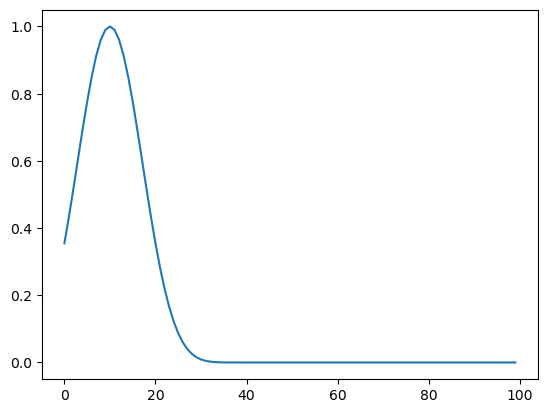

In [ ]:

W_s, subchannels, limit = produce_channel_subdivisions(np.blackman, fft_length=4096, resolution=10)
print(subchannels)